In [2]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df[["URL", "label"]].head())

(235795, 56)
                                  URL  label
0    https://www.southbankmosaics.com      1
1            https://www.uni-mainz.de      1
2      https://www.voicefmradio.co.uk      1
3         https://www.sfnmjournal.com      1
4  https://www.rewildingargentina.org      1


In [3]:
sample_df = df[["URL", "label"]].head(10).copy()

sample_df

,URL,label
0,https://www.southbankmosaics.com,1
1,https://www.uni-mainz.de,1
2,https://www.voicefmradio.co.uk,1
3,https://www.sfnmjournal.com,1
4,https://www.rewildingargentina.org,1
5,https://www.globalreporting.org,1
6,https://www.saffronart.com,1
7,https://www.nerdscandy.com,1
8,https://www.hyderabadonline.in,1
9,https://www.aap.org,1


In [4]:
from urllib.parse import urlparse

test_url = "https://secure.example.com/login?id=123"

parsed = urlparse(test_url)

print("Scheme :", parsed.scheme)
print("Domain :", parsed.hostname)
print("Path   :", parsed.path)
print("Query  :", parsed.query)

Scheme : https
Domain : secure.example.com
Path   : /login
Query  : id=123


In [5]:
def normalize_url(url):
    url = str(url).strip()

    if not url.startswith(("http://", "https://")):
        url = "http://" + url

    return url

print(normalize_url("google.com/login"))
print(normalize_url("https://google.com/login"))

http://google.com/login
https://google.com/login


In [6]:
import re
import ipaddress
import math
from collections import Counter
from urllib.parse import urlparse


def calculate_entropy(text):
    if not text:
        return 0.0

    probabilities = [
        count / len(text)
        for count in Counter(text).values()
    ]

    return -sum(
        p * math.log2(p)
        for p in probabilities
    )


def is_ip_address(hostname):
    if not hostname:
        return 0

    try:
        ipaddress.ip_address(hostname)
        return 1
    except ValueError:
        return 0


def extract_url_features(url):

    original_url = str(url).strip()
    normalized_url = normalize_url(original_url)

    parsed = urlparse(normalized_url)

    hostname = parsed.hostname or ""
    path = parsed.path or ""
    query = parsed.query or ""

    features = {}

    # -------------------------------
    # Length-based features
    # -------------------------------

    features["url_length"] = len(original_url)
    features["domain_length"] = len(hostname)
    features["path_length"] = len(path)
    features["query_length"] = len(query)

    # -------------------------------
    # Character counts
    # -------------------------------

    features["dot_count"] = original_url.count(".")
    features["hyphen_count"] = original_url.count("-")
    features["underscore_count"] = original_url.count("_")
    features["slash_count"] = original_url.count("/")
    features["question_count"] = original_url.count("?")
    features["equal_count"] = original_url.count("=")
    features["ampersand_count"] = original_url.count("&")
    features["at_count"] = original_url.count("@")
    features["percent_count"] = original_url.count("%")

    # -------------------------------
    # Letters and digits
    # -------------------------------

    features["digit_count"] = sum(
        char.isdigit() for char in original_url
    )

    features["letter_count"] = sum(
        char.isalpha() for char in original_url
    )

    if len(original_url) > 0:

        features["digit_ratio"] = (
            features["digit_count"] / len(original_url)
        )

        features["letter_ratio"] = (
            features["letter_count"] / len(original_url)
        )

    else:
        features["digit_ratio"] = 0
        features["letter_ratio"] = 0

    # -------------------------------
    # Protocol / domain
    # -------------------------------

    features["is_https"] = int(
        parsed.scheme.lower() == "https"
    )

    features["is_domain_ip"] = is_ip_address(hostname)

    # -------------------------------
    # Subdomain approximation
    # -------------------------------

    hostname_parts = hostname.split(".")

    if features["is_domain_ip"]:
        features["subdomain_count"] = 0

    elif len(hostname_parts) > 2:
        features["subdomain_count"] = len(hostname_parts) - 2

    else:
        features["subdomain_count"] = 0

    # -------------------------------
    # Suspicious keywords
    # -------------------------------

    suspicious_words = [
        "login",
        "signin",
        "verify",
        "verification",
        "secure",
        "account",
        "update",
        "bank",
        "payment",
        "confirm",
        "password",
        "credential",
        "wallet"
    ]

    lower_url = original_url.lower()

    features["suspicious_word_count"] = sum(
        word in lower_url
        for word in suspicious_words
    )

    # -------------------------------
    # URL entropy
    # -------------------------------

    features["url_entropy"] = calculate_entropy(original_url)

    return features

In [7]:
test_url = "https://secure-bank-login.com/account/verify?id=12345"

test_features = extract_url_features(test_url)

for feature, value in test_features.items():
    print(f"{feature:25} : {value}")

url_length                : 53
domain_length             : 21
path_length               : 15
query_length              : 8
dot_count                 : 1
hyphen_count              : 2
underscore_count          : 0
slash_count               : 4
question_count            : 1
equal_count               : 1
ampersand_count           : 0
at_count                  : 0
percent_count             : 0
digit_count               : 5
letter_count              : 38
digit_ratio               : 0.09433962264150944
letter_ratio              : 0.7169811320754716
is_https                  : 1
is_domain_ip              : 0
subdomain_count           : 0
suspicious_word_count     : 5
url_entropy               : 4.788780124170419


In [8]:
ip_test = "http://192.168.1.100/login?id=123"

extract_url_features(ip_test)

{'url_length': 33,
 'domain_length': 13,
 'path_length': 6,
 'query_length': 6,
 'dot_count': 3,
 'hyphen_count': 0,
 'underscore_count': 0,
 'slash_count': 3,
 'question_count': 1,
 'equal_count': 1,
 'ampersand_count': 0,
 'at_count': 0,
 'percent_count': 0,
 'digit_count': 13,
 'letter_count': 11,
 'digit_ratio': 0.3939393939393939,
 'letter_ratio': 0.3333333333333333,
 'is_https': 0,
 'is_domain_ip': 1,
 'subdomain_count': 0,
 'suspicious_word_count': 1,
 'url_entropy': 4.161987589698946}

In [9]:
normal_test = "https://www.example.com/products"

extract_url_features(normal_test)

{'url_length': 32,
 'domain_length': 15,
 'path_length': 9,
 'query_length': 0,
 'dot_count': 2,
 'hyphen_count': 0,
 'underscore_count': 0,
 'slash_count': 3,
 'question_count': 0,
 'equal_count': 0,
 'ampersand_count': 0,
 'at_count': 0,
 'percent_count': 0,
 'digit_count': 0,
 'letter_count': 26,
 'digit_ratio': 0.0,
 'letter_ratio': 0.8125,
 'is_https': 1,
 'is_domain_ip': 0,
 'subdomain_count': 1,
 'suspicious_word_count': 0,
 'url_entropy': 4.030639062229566}

In [10]:
suspicious_test = (
    "http://secure-account-login-verification-example.com/"
    "verify?id=893472"
)

extract_url_features(suspicious_test)

{'url_length': 69,
 'domain_length': 45,
 'path_length': 7,
 'query_length': 9,
 'dot_count': 1,
 'hyphen_count': 4,
 'underscore_count': 0,
 'slash_count': 3,
 'question_count': 1,
 'equal_count': 1,
 'ampersand_count': 0,
 'at_count': 0,
 'percent_count': 0,
 'digit_count': 6,
 'letter_count': 52,
 'digit_ratio': 0.08695652173913043,
 'letter_ratio': 0.7536231884057971,
 'is_https': 0,
 'is_domain_ip': 0,
 'subdomain_count': 0,
 'suspicious_word_count': 5,
 'url_entropy': 4.693325319216654}

In [11]:
pd.DataFrame(
    [extract_url_features(test_url)]
)

,url_length,domain_length,path_length,query_length,dot_count,hyphen_count,underscore_count,slash_count,question_count,equal_count,...,percent_count,digit_count,letter_count,digit_ratio,letter_ratio,is_https,is_domain_ip,subdomain_count,suspicious_word_count,url_entropy
0,53,21,15,8,1,2,0,4,1,1,...,0,5,38,0.09434,0.716981,1,0,0,5,4.78878


In [12]:
sample_features = sample_df["URL"].apply(
    extract_url_features
)

sample_feature_df = pd.DataFrame(
    sample_features.tolist()
)

sample_feature_df["label"] = sample_df["label"].values

sample_feature_df.head()


,url_length,domain_length,path_length,query_length,dot_count,hyphen_count,underscore_count,slash_count,question_count,equal_count,...,digit_count,letter_count,digit_ratio,letter_ratio,is_https,is_domain_ip,subdomain_count,suspicious_word_count,url_entropy,label
0,32,24,0,0,2,0,0,2,0,0,...,0,27,0.0,0.843750,1,0,1,1,3.929229,1
1,24,16,0,0,2,1,0,2,0,0,...,0,18,0.0,0.750000,1,0,1,0,3.970176,1
2,30,22,0,0,3,0,0,2,0,0,...,0,24,0.0,0.800000,1,0,2,0,4.164735,1
3,27,19,0,0,2,0,0,2,0,0,...,0,22,0.0,0.814815,1,0,1,0,4.060262,1
4,34,26,0,0,2,0,0,2,0,0,...,0,29,0.0,0.852941,1,0,1,0,3.917626,1


In [13]:
print(sample_feature_df.shape)
print(sample_feature_df.dtypes)

(10, 23)
url_length                 int64
domain_length              int64
path_length                int64
query_length               int64
dot_count                  int64
hyphen_count               int64
underscore_count           int64
slash_count                int64
question_count             int64
equal_count                int64
ampersand_count            int64
at_count                   int64
percent_count              int64
digit_count                int64
letter_count               int64
digit_ratio              float64
letter_ratio             float64
is_https                   int64
is_domain_ip               int64
subdomain_count            int64
suspicious_word_count      int64
url_entropy              float64
label                      int64
dtype: object


In [14]:
print(
    "Missing values:",
    sample_feature_df.isnull().sum().sum()
)

feature_only_sample = sample_feature_df.drop(
    columns=["label"]
)

print(
    "Infinite values:",
    np.isinf(feature_only_sample).sum().sum()
)

Missing values: 0
Infinite values: 0


In [15]:
validation_df = df.head(1000).copy()

generated_validation = pd.DataFrame(
    validation_df["URL"]
    .apply(extract_url_features)
    .tolist()
)

In [16]:
url_length_match = (
    generated_validation["url_length"].values
    ==
    validation_df["URLLength"].values
)

print(
    "URLLength match rate:",
    url_length_match.mean()
)

URLLength match rate: 0.089


In [17]:
length_check = validation_df[["URL", "URLLength"]].copy()

length_check["our_url_length"] = (
    generated_validation["url_length"].values
)

length_check["python_raw_length"] = (
    validation_df["URL"]
    .astype(str)
    .str.len()
    .values
)

length_check["difference"] = (
    length_check["our_url_length"]
    - length_check["URLLength"]
)

length_check.head(20)

,URL,URLLength,our_url_length,python_raw_length,difference
0,https://www.southbankmosaics.com,31,32,32,1
1,https://www.uni-mainz.de,23,24,24,1
2,https://www.voicefmradio.co.uk,29,30,30,1
3,https://www.sfnmjournal.com,26,27,27,1
4,https://www.rewildingargentina.org,33,34,34,1
5,https://www.globalreporting.org,30,31,31,1
6,https://www.saffronart.com,25,26,26,1
7,https://www.nerdscandy.com,25,26,26,1
8,https://www.hyderabadonline.in,29,30,30,1
9,https://www.aap.org,18,19,19,1


In [18]:
print(
    "Raw Python length vs dataset match rate:",
    (
        length_check["python_raw_length"]
        == length_check["URLLength"]
    ).mean()
)

print(
    length_check["difference"]
    .value_counts()
    .head(20)
)

Raw Python length vs dataset match rate: 0.089
difference
1    911
0     89
Name: count, dtype: int64


In [19]:
mismatches = length_check[
    length_check["our_url_length"]
    != length_check["URLLength"]
]

print("Total mismatches:", len(mismatches))

display(
    mismatches[
        [
            "URL",
            "URLLength",
            "our_url_length",
            "python_raw_length",
            "difference"
        ]
    ].head(15)
)

Total mismatches: 911


,URL,URLLength,our_url_length,python_raw_length,difference
0,https://www.southbankmosaics.com,31,32,32,1
1,https://www.uni-mainz.de,23,24,24,1
2,https://www.voicefmradio.co.uk,29,30,30,1
3,https://www.sfnmjournal.com,26,27,27,1
4,https://www.rewildingargentina.org,33,34,34,1
5,https://www.globalreporting.org,30,31,31,1
6,https://www.saffronart.com,25,26,26,1
7,https://www.nerdscandy.com,25,26,26,1
8,https://www.hyderabadonline.in,29,30,30,1
9,https://www.aap.org,18,19,19,1


### URLLength Validation Finding

The custom URL feature extractor was compared with the dataset-provided
`URLLength` feature using the first 1,000 samples.

- Exact match rate: 8.9%
- 89 samples matched exactly.
- 911 samples differed by exactly +1.
- The custom `url_length` matched Python's raw string length calculation.

This indicates that the dataset-provided `URLLength` was generated using
a slightly different preprocessing or length convention.

For the deployment-safe pipeline, the custom definition
`len(original_url)` is retained rather than artificially modifying the
feature to reproduce the dataset value.

The same custom feature extractor will be used during both model training
and inference, ensuring training-inference consistency.

In [20]:
domain_length_match = (
    generated_validation["domain_length"].values
    ==
    validation_df["DomainLength"].values
)

print(
    "DomainLength match rate:",
    domain_length_match.mean()
)

DomainLength match rate: 1.0


In [21]:
https_match = (
    generated_validation["is_https"].values
    ==
    validation_df["IsHTTPS"].values
)

print(
    "IsHTTPS match rate:",
    https_match.mean()
)

IsHTTPS match rate: 0.999


In [22]:
ip_match = (
    generated_validation["is_domain_ip"].values
    ==
    validation_df["IsDomainIP"].values
)

print(
    "IsDomainIP match rate:",
    ip_match.mean()
)

IsDomainIP match rate: 1.0


In [26]:
print("Generating deployment-safe URL features...")

generated_features = pd.DataFrame(
    df["URL"]
    .apply(extract_url_features)
    .tolist()
)

generated_features["label"] = df["label"].values

print("Completed.")
print("Shape:", generated_features.shape)

Generating deployment-safe URL features...
Completed.
Shape: (235795, 23)


In [27]:
generated_features.head()
generated_features.info()
generated_features.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   url_length             235795 non-null  int64  
 1   domain_length          235795 non-null  int64  
 2   path_length            235795 non-null  int64  
 3   query_length           235795 non-null  int64  
 4   dot_count              235795 non-null  int64  
 5   hyphen_count           235795 non-null  int64  
 6   underscore_count       235795 non-null  int64  
 7   slash_count            235795 non-null  int64  
 8   question_count         235795 non-null  int64  
 9   equal_count            235795 non-null  int64  
 10  ampersand_count        235795 non-null  int64  
 11  at_count               235795 non-null  int64  
 12  percent_count          235795 non-null  int64  
 13  digit_count            235795 non-null  int64  
 14  letter_count           235795 non-null  int64  

,count,mean,std,min,25%,50%,75%,max
url_length,235795.0,35.366954,41.214346,14.000000,24.000000,28.000000,35.000000,6097.000000
domain_length,235795.0,21.468899,9.149127,4.000000,16.000000,20.000000,24.000000,110.000000
path_length,235795.0,3.735325,23.501818,0.000000,0.000000,0.000000,1.000000,4248.000000
query_length,235795.0,2.212977,24.880892,0.000000,0.000000,0.000000,0.000000,3391.000000
dot_count,235795.0,2.257143,0.922678,1.000000,2.000000,2.000000,2.000000,99.000000
hyphen_count,235795.0,0.350249,1.521763,0.000000,0.000000,0.000000,0.000000,286.000000
underscore_count,235795.0,0.034950,0.551745,0.000000,0.000000,0.000000,0.000000,86.000000
slash_count,235795.0,2.436328,1.045839,2.000000,2.000000,2.000000,3.000000,68.000000
question_count,235795.0,0.029454,0.193629,0.000000,0.000000,0.000000,0.000000,4.000000
equal_count,235795.0,0.063297,0.936883,0.000000,0.000000,0.000000,0.000000,176.000000


In [28]:
print(
    "Missing values:",
    generated_features.isnull().sum().sum()
)

X_temp = generated_features.drop(columns=["label"])

print(
    "Infinite values:",
    np.isinf(X_temp).sum().sum()
)

print(
    "Duplicate feature rows:",
    generated_features.duplicated().sum()
)

Missing values: 0
Infinite values: 0
Duplicate feature rows: 169593


In [29]:
print(
    generated_features["label"].value_counts()
)

print(
    generated_features["label"]
    .value_counts(normalize=True)
    * 100
)

label
1    134850
0    100945
Name: count, dtype: int64
label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


In [30]:
engineered_corr = (
    generated_features
    .corr()["label"]
    .drop("label")
    .sort_values(ascending=False)
)

print(engineered_corr)

is_https                 0.612874
letter_ratio             0.350577
subdomain_count          0.004076
percent_count           -0.034622
is_domain_ip            -0.058766
underscore_count        -0.073213
equal_count             -0.078087
at_count                -0.084218
ampersand_count         -0.088742
query_length            -0.102800
dot_count               -0.119606
question_count          -0.175813
digit_count             -0.178386
suspicious_word_count   -0.182966
path_length             -0.183701
hyphen_count            -0.202825
letter_count            -0.212528
url_length              -0.228229
domain_length           -0.283014
url_entropy             -0.397028
digit_ratio             -0.433433
slash_count             -0.482206
Name: label, dtype: float64


In [31]:
engineered_abs_corr = (
    generated_features
    .corr()["label"]
    .drop("label")
    .abs()
    .sort_values(ascending=False)
)

print(engineered_abs_corr)

is_https                 0.612874
slash_count              0.482206
digit_ratio              0.433433
url_entropy              0.397028
letter_ratio             0.350577
domain_length            0.283014
url_length               0.228229
letter_count             0.212528
hyphen_count             0.202825
path_length              0.183701
suspicious_word_count    0.182966
digit_count              0.178386
question_count           0.175813
dot_count                0.119606
query_length             0.102800
ampersand_count          0.088742
at_count                 0.084218
equal_count              0.078087
underscore_count         0.073213
is_domain_ip             0.058766
percent_count            0.034622
subdomain_count          0.004076
Name: label, dtype: float64


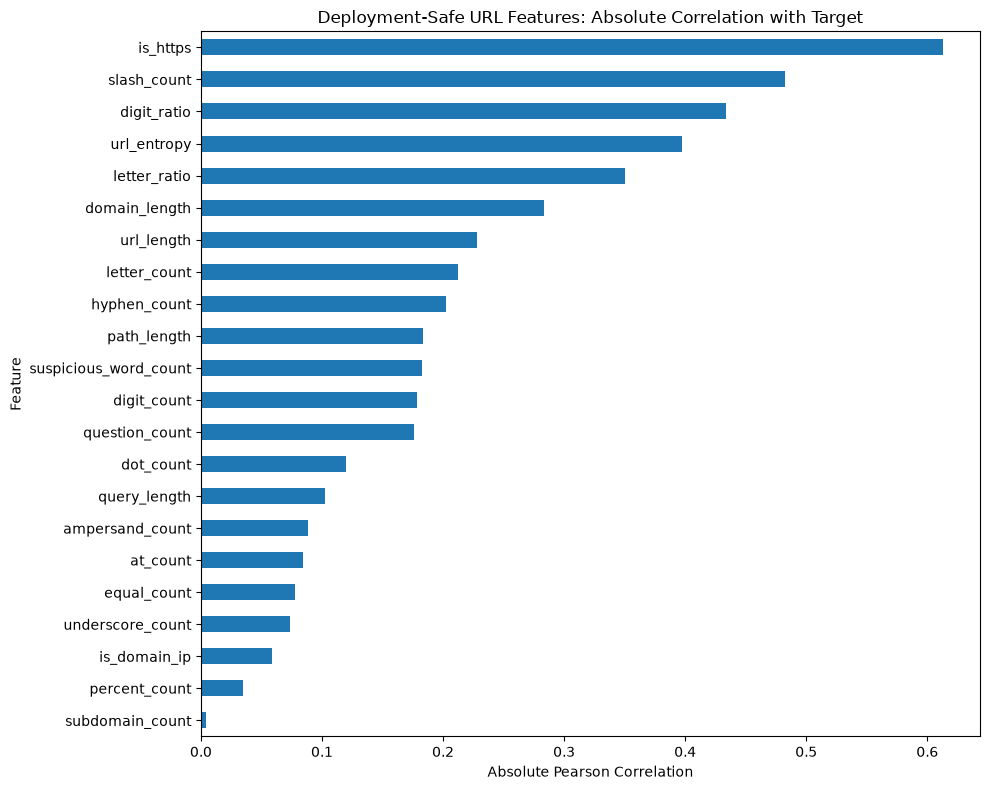

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

engineered_abs_corr.sort_values().plot(
    kind="barh"
)

plt.title(
    "Deployment-Safe URL Features: "
    "Absolute Correlation with Target"
)

plt.xlabel("Absolute Pearson Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [33]:
feature_corr = (
    generated_features
    .drop(columns=["label"])
    .corr()
    .abs()
)

upper = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)

high_corr = (
    upper.stack()
    .sort_values(ascending=False)
)

print(
    high_corr[
        high_corr > 0.90
    ]
)

url_length  letter_count    0.95603
dtype: float64


In [34]:
import os

OUTPUT_PATH = "../data/processed/deployment_url_features.csv"

os.makedirs(
    "../data/processed",
    exist_ok=True
)

generated_features.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved:", OUTPUT_PATH)

Saved: ../data/processed/deployment_url_features.csv


In [35]:
print("=" * 70)
print("PHASE 4 — FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print(f"Original samples       : {len(df):,}")
print(f"Generated samples      : {len(generated_features):,}")

print(
    f"Engineered predictors  : "
    f"{generated_features.shape[1] - 1}"
)

print(
    f"Missing values         : "
    f"{generated_features.isnull().sum().sum():,}"
)

print(
    f"Phishing samples (0)   : "
    f"{(generated_features['label'] == 0).sum():,}"
)

print(
    f"Legitimate samples (1) : "
    f"{(generated_features['label'] == 1).sum():,}"
)

print("\nTop engineered features:")
print(engineered_abs_corr.head(10))

PHASE 4 — FEATURE ENGINEERING SUMMARY
Original samples       : 235,795
Generated samples      : 235,795
Engineered predictors  : 22
Missing values         : 0
Phishing samples (0)   : 100,945
Legitimate samples (1) : 134,850

Top engineered features:
is_https         0.612874
slash_count      0.482206
digit_ratio      0.433433
url_entropy      0.397028
letter_ratio     0.350577
domain_length    0.283014
url_length       0.228229
letter_count     0.212528
hyphen_count     0.202825
path_length      0.183701
Name: label, dtype: float64
